# ARP 299: multiwavelength (neutrino + gamma-ray) flux

This notebook compares the model's predicted SED for Arp 299 against its observed gamma-ray SED
(Ajello et al. 2020, ApJ 894, 88), CTAO North sensitivity (50 hrs), and IceCube
point-source sensitivity (10 years).

To do's: 
* add IceCube-Gen2 point-source sensitivity
* add unc at 1 GeV for gamma predictions

In [1]:
#General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Own-code imports
from repo_root import *
from helper_functions.analytic_neutrino_flux import Flux
from helper_functions.gamma_flux import Flux_gamma

C:\Users\merck\miniforge3\envs\gamma-space\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
ARP 299 multiwavelength SED plot (neutrinos + gamma-rays, internal+EBL
absorption only) with CTAO North sensitivity, IceCube point-source
sensitivity, and observational data points / upper limits.

"""

# --- Conversion constants ---
ERG_TO_GEV = 624.15            # 1 erg = 624.15 GeV
GEV_TO_ERG = 1.0 / ERG_TO_GEV  # 1 GeV = 1/624.15 erg

# --- Data location ---
DATA_DIR = repo_root / "data" / "arp299"
CTAO_DIR = repo_root / "data" / "ctao-sensitivity"


def load_xy(path, convert_erg_to_gev=False):
    """Load a two-column (X, Y) CSV with ';' separators and ',' decimals.

    Set convert_erg_to_gev=True only if this particular file's Y column
    is in erg cm^-2 s^-1 and needs converting to GeV cm^-2 s^-1. The
    ARP299 files are already in GeV (they get converted to erg later,
    right before plotting, since this whole script plots in erg).
    """
    df = pd.read_csv(path, sep=';', header=None, names=['X', 'Y'], decimal=',')
    df = df.astype(float)
    if convert_erg_to_gev:
        df['Y'] *= ERG_TO_GEV
    return df.X.values, df.Y.values

## ARP 299 data points, upper limits, and their error boxes

In [3]:
# ARP 299 gamma-ray SED (Fermi-LAT, Ajello et al. 2020, ApJ 894, 88)
# Loaded directly from the VizieR catalog table (per-bin flux / upper limits),

MEV_TO_ERG = 1.602176634e-6  # 1 MeV = 1.602176634e-6 erg

# Spectral-index uncertainty 
# (plot cell) to tilt the *model* prediction band. Unrelated to the
# observational points themselves, which are loaded fresh below.
ARP299_E0_GEV = 1.0
ARP299_GAMMA_ERR = 0.19

_arp299 = pd.read_csv(DATA_DIR / "arp299_gamma_ray_seds.csv")

_E = _arp299["E_MeV"].values / 1000.0          # MeV -> GeV
_E_lo = _arp299["E_low_MeV"].values / 1000.0
_E_hi = _arp299["E_high_MeV"].values / 1000.0
_flux = _arp299["Flux_MeV_cm2_s"].values * MEV_TO_ERG
_e_flux = _arp299["e_Flux_MeV_cm2_s"].values * MEV_TO_ERG
_limit = _arp299["Limit_MeV_cm2_s"].values * MEV_TO_ERG

_detected = ~np.isnan(_flux)
_upper_lim = ~np.isnan(_limit)

# Detections
XARP299data, YARP299data = _E[_detected], _flux[_detected]
XminARP299data, XmaxARP299data = _E_lo[_detected], _E_hi[_detected]
YminARP299data = YARP299data - _e_flux[_detected]
YmaxARP299data = YARP299data + _e_flux[_detected]

# Upper limits
XARP299upper, YARP299upper = _E[_upper_lim], _limit[_upper_lim]
XminARP299upper, XmaxARP299upper = _E_lo[_upper_lim], _E_hi[_upper_lim]
YminARP299upper = YARP299upper * 0.7  # arrow length for display only

## 1. CTAO North sensitivity curve (source file is already erg cm^-2 s^-1)

In [4]:
CTAO_NORTH_CSV = CTAO_DIR / "CTAOdata_North_50h.csv"

data_north = pd.read_csv(
    CTAO_NORTH_CSV, sep=';', header=None, names=['X', 'Y'], decimal=','
)
X_north = data_north['X'].astype('float64') * 1e3   # TeV -> GeV
Y_north = data_north['Y'].astype('float64')          # already erg cm^-2 s^-1

## 2. IceCube point-source sensitivity (flat E^2F segment)

In [5]:
E_ICECUBE_MIN_GEV = 10 ** 2.6872787803397697
E_ICECUBE_MAX_GEV = 10 ** 4.211878106089287
SENS_ICECUBE_ARP299AA_GEV = 5.785154691896414e-13 * (1 / 1000) * (1e3) ** 2  # GeV cm^-2 s^-1
SENS_ICECUBE_ARP299AA = SENS_ICECUBE_ARP299AA_GEV * GEV_TO_ERG               # erg cm^-2 s^-1

E_sens_icecube = np.linspace(E_ICECUBE_MIN_GEV, E_ICECUBE_MAX_GEV, 500)
Flux_sens_icecube = np.full_like(E_sens_icecube, SENS_ICECUBE_ARP299AA)

## 3. Energy grids

In [6]:
E_nu = np.logspace(2, 7, 300)       # GeV
E_gamma = np.logspace(-2, 7, 300)   # GeV


## 4. Source / transport parameters (single "Internal + EBL" config)

In [7]:
BASELINE_PARAMS = dict(
    R=250,       # pc
    H=150,       # cylindrical geometry
    v_wind=500,  # km/s
    nism=2500,   # cm^-3
    gammasn=4.11,
    pmax=1e6,    # GeV 
    RSN=0.32,    # yr^-1
    D_L=50.7,    # Mpc
)

GAMMA_KWARGS = dict(
    internal_abs=True,
    z=0.01,
    T_dust=50,
    escape_model="volume",
)

## 5. Plot

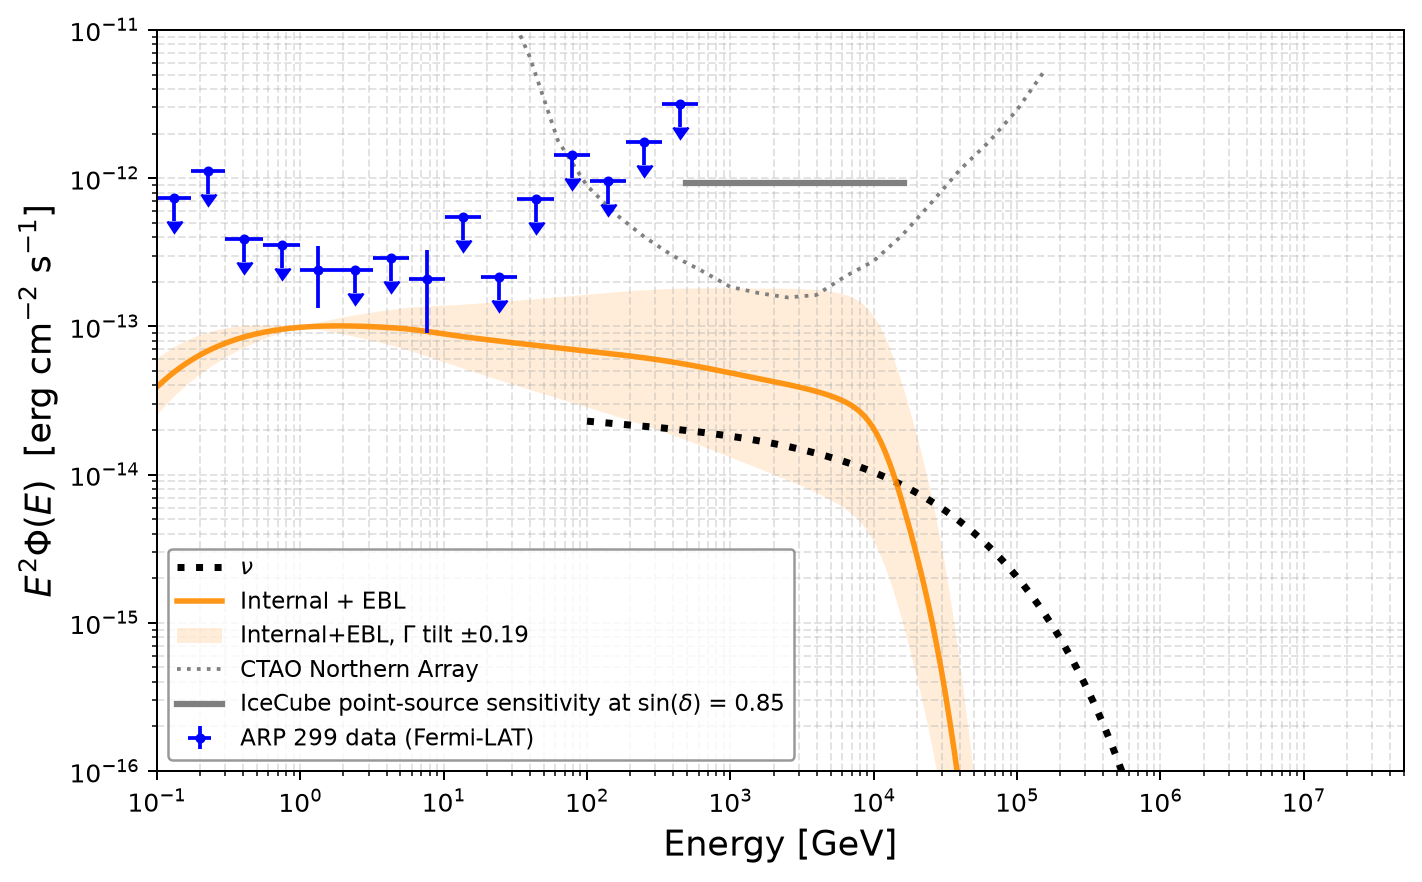

In [8]:
plt.figure(figsize=(8, 5), dpi=180)

# Neutrino curve (not affected by internal/EBL absorption)
F_nu = Flux(
    E_nu, BASELINE_PARAMS['R'], BASELINE_PARAMS['v_wind'], BASELINE_PARAMS['nism'],
    BASELINE_PARAMS['H'], BASELINE_PARAMS['gammasn'], BASELINE_PARAMS['pmax'],
    BASELINE_PARAMS['RSN'], BASELINE_PARAMS['D_L'],
) * GEV_TO_ERG
plt.loglog(E_nu, F_nu, linestyle=':', linewidth=2.8, color="black", label=r"$\nu$")

# Gamma-ray curve, Internal absorption + EBL only
F_gamma = Flux_gamma(
    E_gamma, BASELINE_PARAMS['R'], BASELINE_PARAMS['v_wind'], BASELINE_PARAMS['nism'],
    BASELINE_PARAMS['H'], BASELINE_PARAMS['gammasn'], BASELINE_PARAMS['pmax'],
    BASELINE_PARAMS['RSN'], BASELINE_PARAMS['D_L'],
    z=GAMMA_KWARGS['z'],
    internal_abs=GAMMA_KWARGS['internal_abs'],
    T_dust=GAMMA_KWARGS['T_dust'],
    escape_model=GAMMA_KWARGS['escape_model'],
) * GEV_TO_ERG
plt.loglog(E_gamma, F_gamma, linestyle='-', linewidth=2.2, color="darkorange",
           alpha=0.9, label="Internal + EBL")

# Uncertainty band on the Internal+EBL prediction itself: no separate
# error bars exist for the model's physical parameters (nism, gammasn,
# etc.), so instead apply the same +/-0.19 spectral-index uncertainty
# (ARP299_GAMMA_ERR, Table 2) directly to the predicted curve, pivoted
# at the same 1 GeV anchor energy. This tilts the whole predicted shape
# (absorption features included) around 1 GeV without changing its
# value there, showing how much the slope uncertainty alone could shift
# the theoretical prediction.
_F_gamma_tilt_lo = F_gamma * (E_gamma / ARP299_E0_GEV) ** (-ARP299_GAMMA_ERR)
_F_gamma_tilt_hi = F_gamma * (E_gamma / ARP299_E0_GEV) ** (ARP299_GAMMA_ERR)
F_gamma_band_lo = np.minimum(_F_gamma_tilt_lo, _F_gamma_tilt_hi)
F_gamma_band_hi = np.maximum(_F_gamma_tilt_lo, _F_gamma_tilt_hi)
plt.fill_between(
    E_gamma, F_gamma_band_lo, F_gamma_band_hi,
    color='darkorange', alpha=0.15, linewidth=0,
    label=r'Internal+EBL, $\Gamma$ tilt $\pm 0.19$',
)

# CTAO North sensitivity
plt.plot(X_north, Y_north, color="gray", label="CTAO Northern Array", ls='dotted')

# IceCube point-source sensitivity
plt.plot(
    E_sens_icecube, Flux_sens_icecube,
    label=r"IceCube point-source sensitivity at sin($\delta$) = 0.85",
    color='grey', linewidth=2.5,
)

# ARP 299 detections (Fermi-LAT, Ajello+2020 VizieR catalog)
plt.errorbar(
    XARP299data, YARP299data,
    xerr=[XARP299data - XminARP299data, XmaxARP299data - XARP299data],
    yerr=[YARP299data - YminARP299data, YmaxARP299data - YARP299data],
    fmt='.', color='blue', label='ARP 299 data (Fermi-LAT)'
)

# ARP 299 upper limits (Fermi-LAT, Ajello+2020 VizieR catalog)
plt.errorbar(
    XARP299upper, YARP299upper,
    xerr=[XARP299upper - XminARP299upper, XmaxARP299upper - XARP299upper],
    yerr=YARP299upper - YminARP299upper,
    fmt='.', color='blue', uplims=True
)

plt.ylim(1e-16, 1e-11)
plt.xlim(1e-1, 5e7)
plt.xlabel("Energy [GeV]", fontsize=14)
plt.ylabel(r"$E^2 \Phi(E)$  [erg cm$^{-2}$ s$^{-1}$]", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend(fontsize=9, loc="lower left", frameon=True, facecolor="white", edgecolor="gray")
plt.tight_layout()
plt.show()